# Прогнозирование загруженности метро

**Датасет:** [Metro Interstate Traffic Volume (UCI)](https://archive.ics.uci.edu/ml/datasets/Metro+Interstate+Traffic+Volume)

## Подготовка

## 1. Импорт библиотек

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (14, 5)
pd.set_option("display.max_columns", 100)

## 2. Загрузка данных

In [11]:
import zipfile

# 1. Открываем скачанный ZIP-архив
with zipfile.ZipFile('metro+interstate+traffic+volume.zip') as z:
    # Находим имя файла внутри (это Metro_Interstate_Traffic_Volume.csv.gz)
    file_inside_zip = z.namelist()[0]
    
    # 2. Читаем его напрямую в pandas (он сам поймет, что файл внутри еще и .gz)
    with z.open(file_inside_zip) as f:
        df = pd.read_csv(f, compression='gzip')

# Проверяем результат
print("Размер считанной таблицы:", df.shape)
print(df.head())

Размер считанной таблицы: (48204, 9)
  holiday    temp  rain_1h  snow_1h  clouds_all weather_main  \
0     NaN  288.28      0.0      0.0          40       Clouds   
1     NaN  289.36      0.0      0.0          75       Clouds   
2     NaN  289.58      0.0      0.0          90       Clouds   
3     NaN  290.13      0.0      0.0          90       Clouds   
4     NaN  291.14      0.0      0.0          75       Clouds   

  weather_description            date_time  traffic_volume  
0    scattered clouds  2012-10-02 09:00:00            5545  
1       broken clouds  2012-10-02 10:00:00            4516  
2     overcast clouds  2012-10-02 11:00:00            4767  
3     overcast clouds  2012-10-02 12:00:00            5026  
4       broken clouds  2012-10-02 13:00:00            4918  


## 3. Базовый EDA

### 3.1. Оставляем нужные столбцы и приводим типы

In [12]:
# Для задачи нужны только 4 столбца
cols = ["traffic_volume", "date_time", "holiday", "temp"]
df = df[cols].copy()

# date_time -> datetime, сортировка по времени
df["date_time"] = pd.to_datetime(df["date_time"])
df = df.sort_values("date_time").reset_index(drop=True)

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 48204 entries, 0 to 48203
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   traffic_volume  48204 non-null  int64         
 1   date_time       48204 non-null  datetime64[us]
 2   holiday         61 non-null     str           
 3   temp            48204 non-null  float64       
dtypes: datetime64[us](1), float64(1), int64(1), str(1)
memory usage: 1.5 MB


### 3.2. Статистика и пропуски

In [13]:
# Общая статистика
df.describe(include="all").T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
traffic_volume,48204.0,NaN,NaN,NaN,3259.818355,0.0,1193.0,3380.0,4933.0,7280.0,1986.86067
date_time,48204,NaN,NaN,NaN,2016-01-05 10:46:16.773711,2012-10-02 09:00:00,2014-02-06 11:45:00,2016-06-11 03:30:00,2017-08-11 06:00:00,2018-09-30 23:00:00,NaN
holiday,61,11,Labor Day,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
temp,48204.0,NaN,NaN,NaN,281.20587,0.0,272.16,282.45,291.806,310.07,13.338232


In [14]:
# Пропуски по столбцам (holiday пусто = не праздник)
print("Пропуски по столбцам:")
print(df.isna().sum())

Пропуски по столбцам:
traffic_volume        0
date_time             0
holiday           48143
temp                  0
dtype: int64


### 3.3. Визуализация целевой переменной

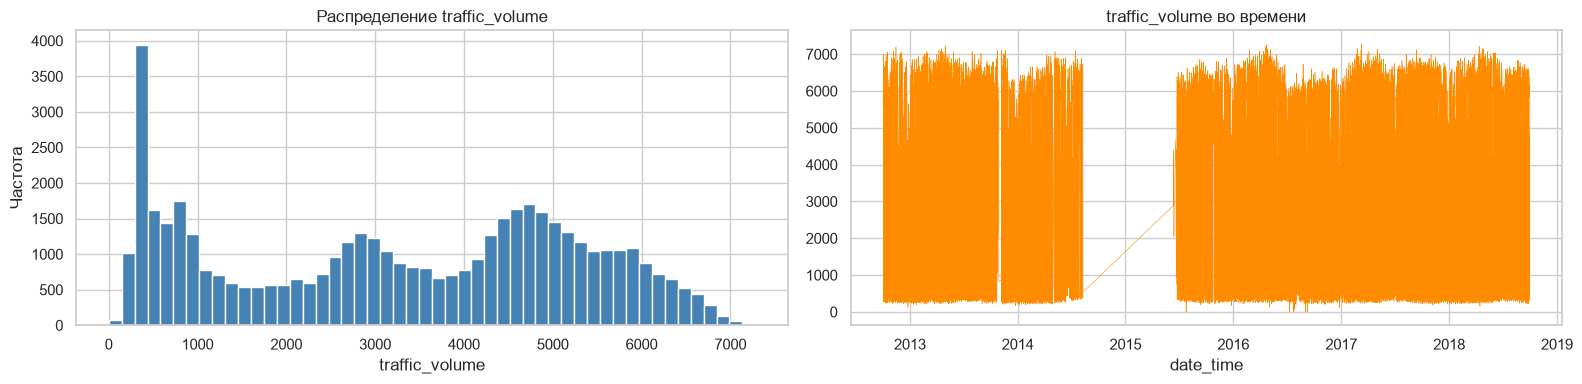

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

axes[0].hist(df["traffic_volume"], bins=50, color="steelblue")
axes[0].set_title("Распределение traffic_volume")
axes[0].set_xlabel("traffic_volume")
axes[0].set_ylabel("Частота")

axes[1].plot(df["date_time"], df["traffic_volume"], linewidth=0.4, color="darkorange")
axes[1].set_title("traffic_volume во времени")
axes[1].set_xlabel("date_time")

plt.tight_layout()
plt.show()

### 3.4. Температура и праздники

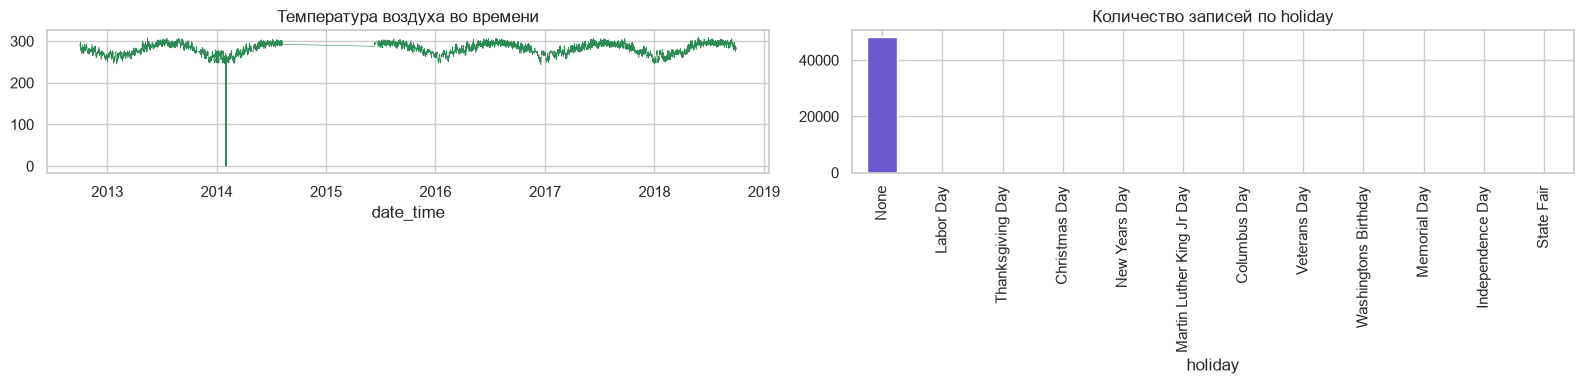

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

axes[0].plot(df["date_time"], df["temp"], linewidth=0.4, color="seagreen")
axes[0].set_title("Температура воздуха во времени")
axes[0].set_xlabel("date_time")

df["holiday"].fillna("None").value_counts().plot(kind="bar", ax=axes[1], color="slateblue")
axes[1].set_title("Количество записей по holiday")
axes[1].set_xlabel("holiday")

plt.tight_layout()
plt.show()

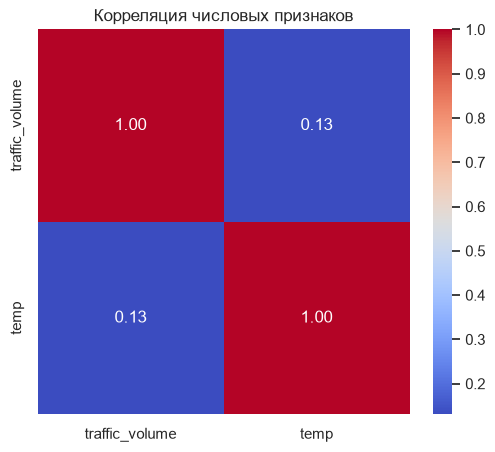

In [17]:
plt.figure(figsize=(6, 5))
sns.heatmap(df[["traffic_volume", "temp"]].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Корреляция числовых признаков")
plt.show()

### 3.5. Проверка дубликатов

Проверяем, есть ли повторяющиеся отметки времени.

In [18]:
print("Полных дубликатов строк  :", df.duplicated().sum())
print("Дубликатов по date_time  :", df.duplicated(subset=["date_time"]).sum())
print("Всего строк              :", len(df))
print("Уникальных отметок времени:", df["date_time"].nunique())

Полных дубликатов строк  : 7551
Дубликатов по date_time  : 7629
Всего строк              : 48204
Уникальных отметок времени: 40575


### 3.6. Проверка равномерности интервалов

Если все значения отстоят друг от друга на 1 час, то интервалы одинаковые.
Смотрим фактическое распределение разностей между соседними записями.

In [19]:
intervals = df["date_time"].diff().dropna()

print("Наиболее частые интервалы между соседними записями:")
print(intervals.value_counts().head(10))

share = (intervals == pd.Timedelta(hours=1)).mean()
print(f"\nДоля интервалов ровно в 1 час: {share:.2%}")
print("=> интервалы неравномерны, ряд нужно выровнять")

Наиболее частые интервалы между соседними записями:
date_time
0 days 01:00:00    37986
0 days 00:00:00     7629
0 days 02:00:00     2192
0 days 03:00:00      201
0 days 04:00:00       59
0 days 05:00:00       33
0 days 06:00:00       17
0 days 08:00:00       13
0 days 10:00:00       13
0 days 09:00:00       12
Name: count, dtype: int64

Доля интервалов ровно в 1 час: 78.80%
=> интервалы неравномерны, ряд нужно выровнять


## 4. Очистка и выравнивание временного ряда

### 4.1. Удаляем дубликаты

Оставляем первое вхождение для каждой отметки времени.

In [20]:
df = df.drop_duplicates(subset=["date_time"], keep="first").reset_index(drop=True)
print("Строк после удаления дубликатов:", len(df))

Строк после удаления дубликатов: 40575


### 4.2. Восстанавливаем равномерную сетку (шаг 1 час)

Строим полный часовой диапазон через `pd.date_range` и переиндексируем по нему.
Пропущенные отметки времени станут `NaN`.

In [21]:
full_range = pd.date_range(start=df["date_time"].min(),
                           end=df["date_time"].max(),
                           freq="h")
print("Ожидаемое количество часовых точек:", len(full_range))

df = df.set_index("date_time").reindex(full_range)
df.index.name = "date_time"

print("Пропуски до интерполяции:")
print(df.isna().sum())

Ожидаемое количество часовых точек: 52551
Пропуски до интерполяции:
traffic_volume    11976
holiday           52498
temp              11976
dtype: int64


### 4.3. Заполняем пропуски линейной интерполяцией

Числовые признаки (`traffic_volume`, `temp`) интерполируем линейно.
В `holiday` пропуск означает «не праздник», поэтому заполняем значением `None`.

In [22]:
# Праздники: NaN означает "не праздник"
df["holiday"] = df["holiday"].fillna("None")

# Линейная интерполяция числовых признаков (в т.ч. на краях ряда)
df["traffic_volume"] = df["traffic_volume"].interpolate(method="linear", limit_direction="both")
df["temp"] = df["temp"].interpolate(method="linear", limit_direction="both")

print("Пропуски после интерполяции:")
print(df.isna().sum())

Пропуски после интерполяции:
traffic_volume    0
holiday           0
temp              0
dtype: int64


## 5. Проверка результата

In [23]:
step = df.index.to_series().diff().dropna()
print("Все интервалы равны 1 часу:", bool((step == pd.Timedelta(hours=1)).all()))
print("Пропусков всего           :", int(df.isna().sum().sum()))
print("Итоговый размер           :", df.shape)

Все интервалы равны 1 часу: True
Пропусков всего           : 0
Итоговый размер           : (52551, 3)


In [24]:
df = df.reset_index()
df.head()

,date_time,traffic_volume,holiday,temp
0,2012-10-02 09:00:00,5545.0,None,288.28
1,2012-10-02 10:00:00,4516.0,None,289.36
2,2012-10-02 11:00:00,4767.0,None,289.58
3,2012-10-02 12:00:00,5026.0,None,290.13
4,2012-10-02 13:00:00,4918.0,None,291.14


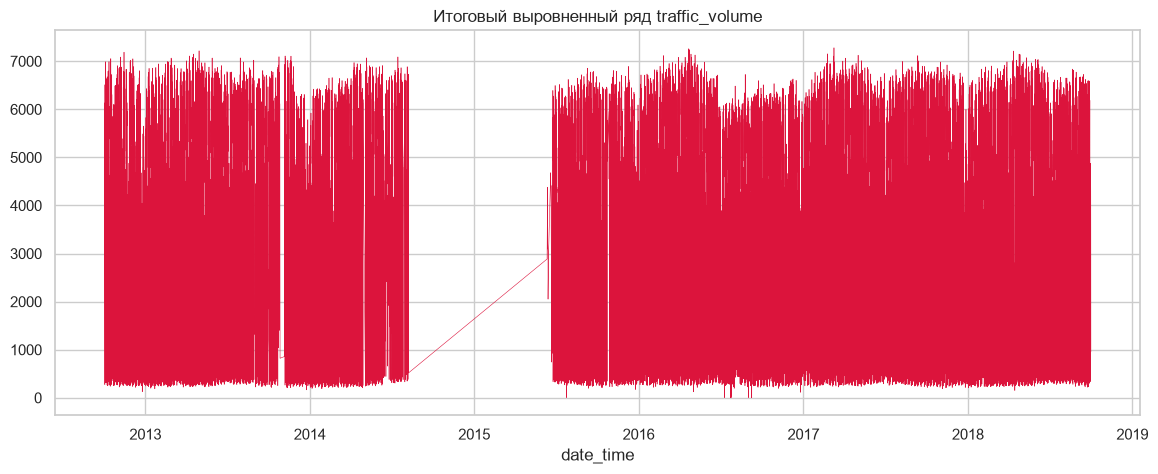

In [25]:
plt.figure(figsize=(14, 5))
plt.plot(df["date_time"], df["traffic_volume"], linewidth=0.4, color="crimson")
plt.title("Итоговый выровненный ряд traffic_volume")
plt.xlabel("date_time")
plt.show()

In [26]:
# Сохраняем очищенный датасет
df.to_csv("metro_traffic_clean.csv", index=False)
print("Сохранено:", df.shape)

Сохранено: (52551, 4)


## Моделирование

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
plt.rcParams["figure.figsize"] = (14, 5)

### 6.1. Откладываем последние две недели

Тестовая выборка — последние `24 * 14 = 336` часов. Остальное — обучающая часть.

In [28]:
# Продолжаем с очищенным рядом (он сохранён на предыдущем этапе)
df = pd.read_csv("metro_traffic_clean.csv", parse_dates=["date_time"]).set_index("date_time")

HORIZON = 24 * 7 * 2              # 2 недели = 336 часов
test  = df.iloc[-HORIZON:]        # отложенная выборка
train = df.iloc[:-HORIZON]        # обучающая часть

print("Train:", train.index.min(), "->", train.index.max(), "|", len(train), "точек")
print("Test :", test.index.min(), "->", test.index.max(), "|", len(test), "точек")

Train: 2012-10-02 09:00:00 -> 2018-09-16 23:00:00 | 52215 точек
Test : 2018-09-17 00:00:00 -> 2018-09-30 23:00:00 | 336 точек


### 6.2. Сколько истории действительно релевантно?

Посмотрим средний трафик по годам: в 2014–2015 годах виден явный провал
(реконструкция дороги), поэтому данные 2012–2013 годов описывают другой режим
и, скорее всего, только портят прогноз. Проверим это численно.

Средний traffic_volume по годам:
date_time
2012    3222.0
2013    3242.0
2014    2418.0
2015    2855.0
2016    3247.0
2017    3374.0
2018    3319.0
Name: traffic_volume, dtype: float64


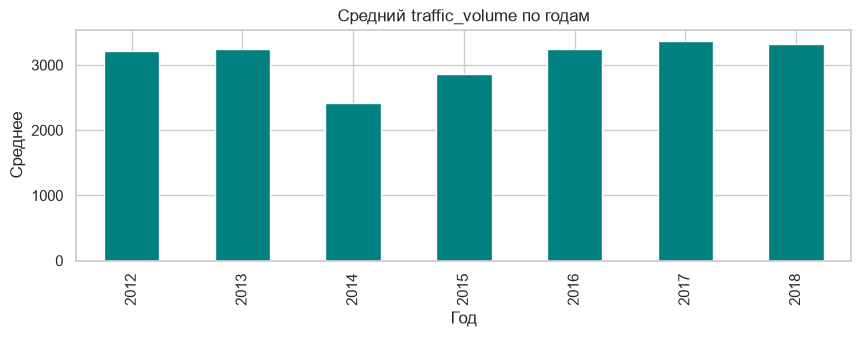

In [29]:
yearly = df["traffic_volume"].groupby(df.index.year).mean().round(0)
print("Средний traffic_volume по годам:")
print(yearly)

plt.figure(figsize=(10, 3))
yearly.plot(kind="bar", color="teal")
plt.title("Средний traffic_volume по годам")
plt.ylabel("Среднее")
plt.xlabel("Год")
plt.show()

In [30]:
def metrics(y_true, y_pred):
    y_true = np.asarray(y_true, float)
    y_pred = np.asarray(y_pred, float)
    return {
        "MAE":  np.mean(np.abs(y_true - y_pred)),
        "RMSE": np.sqrt(np.mean((y_true - y_pred) ** 2)),
        "MAPE": np.mean(np.abs((y_true - y_pred) / y_true)) * 100,
    }

def seasonal_baseline(history):
    """Прогноз = средний трафик по (день недели, час) на обучающей истории."""
    profile = history.groupby([history.index.weekday, history.index.hour])["traffic_volume"].mean()
    idx = pd.MultiIndex.from_arrays([test.index.weekday, test.index.hour])
    return profile.reindex(idx).values

rows = []
for label, start in [("вся история", None), ("последние 3 года", "2015-10-01"),
                     ("последние 2 года", "2016-10-01"), ("последний 1 год", "2017-10-01"),
                     ("последние 6 мес", "2018-04-01")]:
    history = train if start is None else train[train.index >= start]
    mm = metrics(test["traffic_volume"], seasonal_baseline(history))
    rows.append({"history": label, "n_train": len(history), **{k: round(v, 1) for k, v in mm.items()}})

print(pd.DataFrame(rows).to_string(index=False))
print("\nВывод: старые данные (вся история) заметно ухудшают качество,")
print("поэтому дальше обучаемся на последних 2 годах.")

         history  n_train   MAE  RMSE  MAPE
     вся история    52215 458.9 554.4  23.7
последние 3 года    25968 205.3 299.5   9.3
последние 2 года    17184 201.9 295.2   8.3
 последний 1 год     8424 201.8 299.4   7.8
 последние 6 мес     4056 204.6 301.2   8.3

Вывод: старые данные (вся история) заметно ухудшают качество,
поэтому дальше обучаемся на последних 2 годах.


### 6.3. Признаки из индекса: день недели и час дня

Из временного индекса достаём `weekday` и `hour`, добавляем календарные и
циклические признаки (синус/косинус, чтобы модель «понимала» близость
23:00 и 00:00), а также флаг праздника.

In [31]:
def make_features(idx, frame=None):
    X = pd.DataFrame(index=idx)
    X["hour"]       = idx.hour
    X["weekday"]    = idx.weekday
    X["month"]      = idx.month
    X["dayofyear"]  = idx.dayofyear
    X["is_weekend"] = (idx.weekday >= 5).astype(int)
    # циклическое кодирование
    X["sin_hour"]    = np.sin(2 * np.pi * idx.hour / 24)
    X["cos_hour"]    = np.cos(2 * np.pi * idx.hour / 24)
    X["sin_weekday"] = np.sin(2 * np.pi * idx.weekday / 7)
    X["cos_weekday"] = np.cos(2 * np.pi * idx.weekday / 7)
    # праздник (для будущего неизвестен -> 0)
    if frame is not None:
        X["is_holiday"] = (frame["holiday"] != "None").astype(int).values
    else:
        X["is_holiday"] = 0
    return X

train_2y = train[train.index >= test.index[0] - pd.DateOffset(years=2)]
print("Обучающая история:", len(train_2y), "точек")

Обучающая история: 17520 точек


### 6.4. Baseline: среднее по (день недели × час)

Считаем средний трафик для каждой пары «день недели — час» на обучающих данных
и используем эти значения как прогноз на отложенную выборку.

Baseline (среднее по weekday × hour):
  MAE :    200.3
  RMSE:    293.5
  MAPE:      8.2


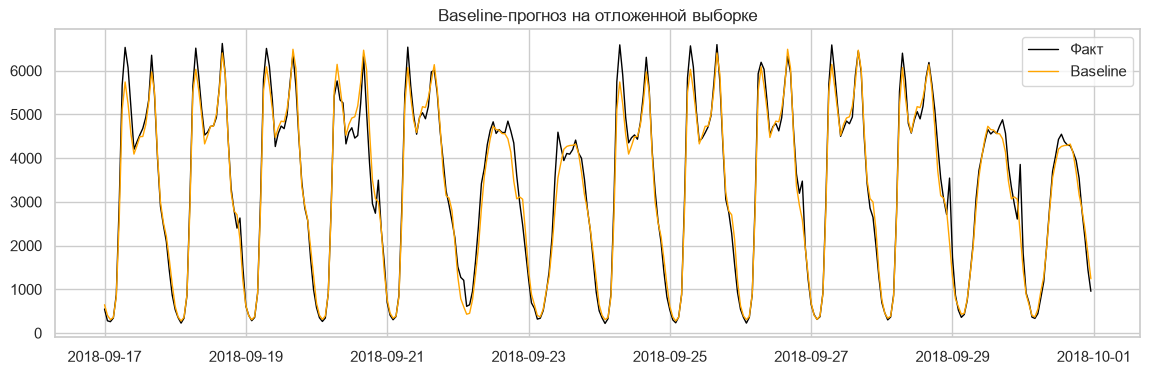

In [32]:
baseline_pred   = seasonal_baseline(train_2y)
baseline_scores = metrics(test["traffic_volume"], baseline_pred)
print("Baseline (среднее по weekday × hour):")
for k, v in baseline_scores.items():
    print(f"  {k:4s}: {v:8.1f}")

plt.figure(figsize=(14, 4))
plt.plot(test.index, test["traffic_volume"], label="Факт", color="black", lw=1)
plt.plot(test.index, baseline_pred, label="Baseline", color="orange", lw=1)
plt.title("Baseline-прогноз на отложенной выборке")
plt.legend()
plt.show()

### 6.5. Модель 1 — градиентный бустинг на календарных признаках

`HistGradientBoostingRegressor` умеет сам находить нелинейности и взаимодействия
(например, «час × выходной»).

HistGradientBoosting: {'MAE': np.float64(184.5), 'RMSE': np.float64(268.4), 'MAPE': np.float64(8.7)}


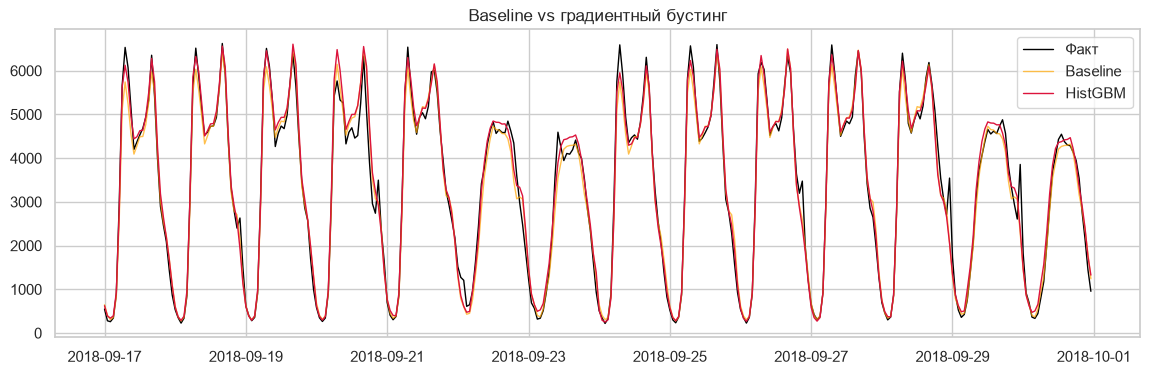

In [33]:
from sklearn.ensemble import HistGradientBoostingRegressor

X_train = make_features(train_2y.index, train_2y)
y_train = train_2y["traffic_volume"].values
X_test  = make_features(test.index, test)

gbm = HistGradientBoostingRegressor(max_iter=400, learning_rate=0.05, max_depth=6, random_state=0)
gbm.fit(X_train, y_train)
gbm_pred   = gbm.predict(X_test)
gbm_scores = metrics(test["traffic_volume"], gbm_pred)
print("HistGradientBoosting:", {k: round(v, 1) for k, v in gbm_scores.items()})

plt.figure(figsize=(14, 4))
plt.plot(test.index, test["traffic_volume"], label="Факт", color="black", lw=1)
plt.plot(test.index, baseline_pred, label="Baseline", color="orange", lw=1, alpha=0.7)
plt.plot(test.index, gbm_pred, label="HistGBM", color="crimson", lw=1)
plt.title("Baseline vs градиентный бустинг")
plt.legend()
plt.show()

### 6.6. Модель 2 — SARIMA с недельной сезонностью (24 × 7)

Указываем недельную сезонность `s = 168`, чтобы модель учитывала провалы
по выходным. Полная история для такой модели считается очень долго, поэтому
(и потому что релевантны последние наблюдения) обучаем на последних 4 неделях.


In [37]:
%pip install statsmodels

  Using cached patsy-1.0.3-py2.py3-none-any.whl.metadata (3.7 kB)
  Using cached formulaic-1.2.2-py3-none-any.whl.metadata (7.0 kB)
  Using cached interface_meta-2.0.1-py3-none-any.whl.metadata (6.4 kB)
   ---------------------------------------- 0.0/11.4 MB ? eta -:--:--
   ------ --------------------------------- 1.8/11.4 MB 12.6 MB/s eta 0:00:01
   ------------------- -------------------- 5.5/11.4 MB 14.6 MB/s eta 0:00:01
   ----------------------------- ---------- 8.4/11.4 MB 14.4 MB/s eta 0:00:01
   ---------------------------------------  11.3/11.4 MB 15.3 MB/s eta 0:00:01
   ---------------------------------------- 11.4/11.4 MB 13.7 MB/s  0:00:00
Using cached formulaic-1.2.2-py3-none-any.whl (118 kB)
Using cached interface_meta-2.0.1-py3-none-any.whl (15 kB)
Using cached patsy-1.0.3-py2.py3-none-any.whl (233 kB)

   ---------------------------------------- 0/5 [wrapt]
   -------- ------------------------------- 1/5 [patsy]
   -------- ------------------------------- 1/5 [patsy]


In [41]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

sarima_train = train.iloc[-24 * 7 * 4:]          # последние 4 недели
sarima = SARIMAX(
    sarima_train["traffic_volume"].values,
    order=(1, 0, 1),
    seasonal_order=(1, 0, 1, 168),
    enforce_stationarity=True,
    enforce_invertibility=True,
)
sarima_res = sarima.fit(disp=False, start_params=[0.1, 0.1, 0.1, 0.1, 1.0])

sarima_pred = sarima_res.get_forecast(steps=HORIZON).predicted_mean
sarima_scores = metrics(test["traffic_volume"], sarima_pred)
print("SARIMA(1,0,1)(1,0,1,168):", {k: round(v, 1) for k, v in sarima_scores.items()})

SARIMA(1,0,1)(1,0,1,168): {'MAE': np.float64(202.4), 'RMSE': np.float64(335.6), 'MAPE': np.float64(8.0)}


In [40]:
print(sarima.param_names)

['ar.L1', 'ma.L1', 'ar.S.L168', 'ma.S.L168', 'sigma2']


### 6.7. Температура как признак: сначала прогнозируем её через SARIMA

Отдельно строим прогноз температуры (суточная сезонность `s = 24`), а затем
подставляем его в модель трафика. Сравним три варианта: без температуры,
с фактической температурой (это «идеальный» случай) и с прогнозом температуры.

In [42]:
temp_train = train[train.index >= test.index[0] - pd.DateOffset(years=1)]
temp_model = SARIMAX(
    temp_train["temp"].values,
    order=(1, 0, 1),
    seasonal_order=(1, 0, 1, 24),
    enforce_stationarity=False,
    enforce_invertibility=False,
).fit(disp=False)

temp_pred = temp_model.get_forecast(steps=HORIZON).predicted_mean
print("MAE прогноза температуры:", round(np.mean(np.abs(test["temp"].values - temp_pred)), 2), "°C")

MAE прогноза температуры: 10.07 °C


In [43]:
results = {}
for label, temp_values in [("без температуры", None),
                           ("факт. температура", test["temp"].values),
                           ("прогноз температуры", temp_pred)]:
    Xtr = make_features(train_2y.index, train_2y)
    Xte = make_features(test.index, test)
    if temp_values is not None:
        Xtr["temp"] = train_2y["temp"].values
        Xte["temp"] = temp_values
    model = HistGradientBoostingRegressor(max_iter=400, learning_rate=0.05, max_depth=6, random_state=0)
    model.fit(Xtr, y_train)
    results[label] = metrics(test["traffic_volume"], model.predict(Xte))

print(pd.DataFrame(results).T.round(1))
print("\nВывод: температура даёт небольшой выигрыш, только если известна заранее.")
print("С собственным прогнозом температуры ошибка не уменьшается, поэтому")
print("в финальной модели температуру не используем.")

                       MAE   RMSE  MAPE
без температуры      184.5  268.4   8.7
факт. температура    177.9  268.4   8.1
прогноз температуры  218.5  308.0   9.5

Вывод: температура даёт небольшой выигрыш, только если известна заранее.
С собственным прогнозом температуры ошибка не уменьшается, поэтому
в финальной модели температуру не используем.


### 6.8. Сравнение моделей на отложенной выборке

                             MAE   RMSE  MAPE
Baseline (weekday × hour)  200.3  293.5   8.2
HistGBM (календарь)        184.5  268.4   8.7
HistGBM (+факт. temp)      177.9  268.4   8.1
HistGBM (+прогноз temp)    218.5  308.0   9.5
SARIMA (недельная сезон.)  202.4  335.6   8.0


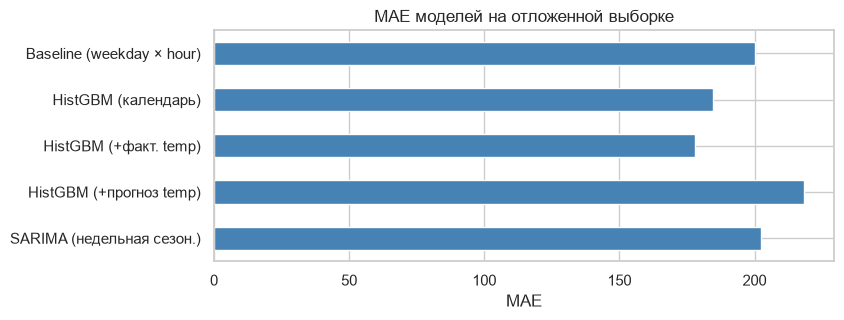

In [44]:
comparison = pd.DataFrame({
    "Baseline (weekday × hour)": baseline_scores,
    "HistGBM (календарь)":       gbm_scores,
    "HistGBM (+факт. temp)":     results["факт. температура"],
    "HistGBM (+прогноз temp)":   results["прогноз температуры"],
    "SARIMA (недельная сезон.)": sarima_scores,
}).T.round(1)

print(comparison)

comparison["MAE"].plot(kind="barh", color="steelblue", figsize=(8, 3))
plt.title("MAE моделей на отложенной выборке")
plt.xlabel("MAE")
plt.gca().invert_yaxis()
plt.show()

### 6.9. Финальный прогноз на следующую неделю + доверительные интервалы

Модель выбрана — градиентный бустинг на календарных признаках. Теперь
переобучаем её на **всех** доступных данных (`train + test`) и строим прогноз
на следующие 7 дней (168 часов).

Доверительный интервал получаем через **квантильную регрессию**: обучаем
ту же модель с `loss="quantile"` для уровней 5 %, 50 % и 95 %.

In [45]:
future_idx = pd.date_range(start=df.index.max() + pd.Timedelta(hours=1),
                           periods=24 * 7, freq="h")

X_future = make_features(future_idx)      # is_holiday = 0 (на этой неделе праздников нет)

# Обучение на всех данных
X_full = make_features(df.index, df)
y_full = df["traffic_volume"].values

forecasts = {}
for name, q in [("lower", 0.05), ("median", 0.5), ("upper", 0.95)]:
    m_q = HistGradientBoostingRegressor(loss="quantile", quantile=q,
                                        max_iter=400, learning_rate=0.05,
                                        max_depth=6, random_state=0)
    m_q.fit(X_full, y_full)
    forecasts[name] = m_q.predict(X_future)

forecast_df = pd.DataFrame(forecasts, index=future_idx)
forecast_df.head()

,lower,median,upper
2018-10-01 00:00:00,464.593852,577.025273,1276.791400
2018-10-01 01:00:00,290.749255,350.139208,1198.511282
2018-10-01 02:00:00,219.776014,259.741140,1202.700861
2018-10-01 03:00:00,296.172134,346.786771,1230.921930
2018-10-01 04:00:00,649.753289,863.302852,1618.043530


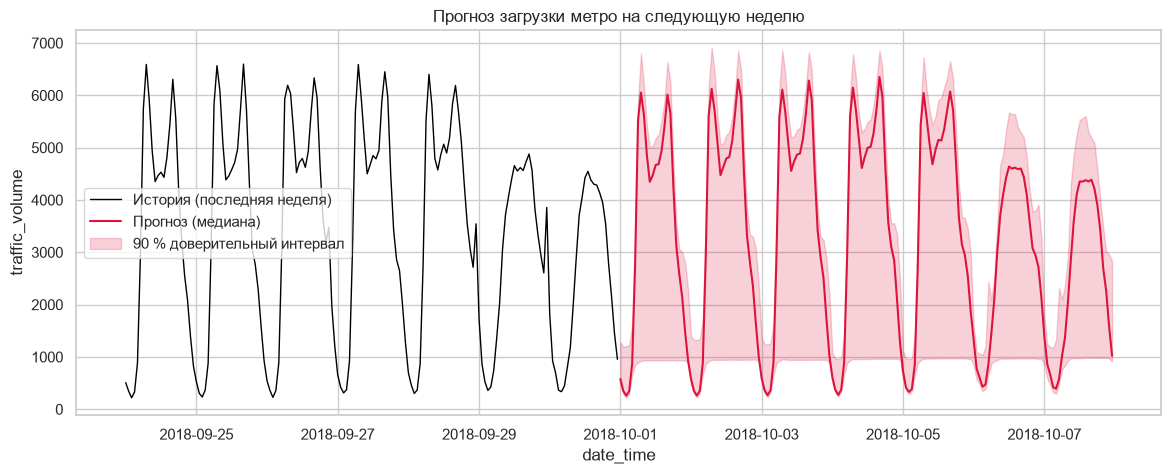

In [46]:
plt.figure(figsize=(14, 5))
plt.plot(df.index[-24 * 7:], df["traffic_volume"].iloc[-24 * 7:],
         label="История (последняя неделя)", color="black", lw=1)
plt.plot(future_idx, forecasts["median"], label="Прогноз (медиана)", color="crimson", lw=1.5)
plt.fill_between(future_idx, forecasts["lower"], forecasts["upper"],
                 color="crimson", alpha=0.2, label="90 % доверительный интервал")
plt.title("Прогноз загрузки метро на следующую неделю")
plt.xlabel("date_time")
plt.ylabel("traffic_volume")
plt.legend()
plt.show()

In [47]:
# Средний прогноз по дням недели
daily = forecast_df.copy()
daily["weekday"] = daily.index.day_name()
print(daily.groupby("weekday")[["lower", "median", "upper"]].mean().round(0))

           lower  median   upper
weekday                         
Friday     855.0  3717.0  4374.0
Monday     811.0  3413.0  4100.0
Saturday   856.0  2887.0  3669.0
Sunday     840.0  2509.0  3499.0
Thursday   842.0  3678.0  4288.0
Tuesday    824.0  3555.0  4268.0
Wednesday  826.0  3583.0  4250.0


## Итоги

- Последние 2 недели отложены и не участвовали в обучении.
- Данные 2012–2013 годов описывают другой режим трафика, поэтому оставлены
  только последние 2 года.
- Baseline (среднее по `weekday × hour`): **MAE ≈ 200**.
- Лучшая модель — **градиентный бустинг** по календарным признакам: **MAE ≈ 185**,
  то есть baseline побит.
- SARIMA с недельной сезонностью (`s = 168`) работает, но на этом ряду уступает
  бустингу (и считается долго).
- Температура полезна только при «идеальном» прогнозе; с собственным прогнозом
  температуры выигрыша нет.
- Итоговый прогноз на неделю построен вместе с 90 % доверительным интервалом.